# RDA GO

> Redundancy analysis genomic offset

The genomic offset based on Redundancy analysis as done in @Capblancq_2021. 

TODO!

In [ ]:
#| default_exp RDA

In [ ]:
#| hide
from fastcore.utils import *
from nbdev.showdoc import *
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
#| export
class RDA:
    "Redundancy analysis genomic offset statistic."
    def __init__(self, K: int):
        self._reg = None
        self._pca = None
        self.K = K
    def __str__(self):
        return f"Redundancy analysis model with K={self.K}"
    __repr__ = __str__

In order to use the model we have first to initialize it with a maximum number of canonical axes `K`. 

In [ ]:
K = 2
model = RDA(K)

Then, we have to fit the model ...

In [ ]:
#|export
@patch
def fit(self:RDA,
        Y: np.ndarray, # Allele frequency matrix (nxL)
        X: np.ndarray): # Environmental matrix (nxP)
    "Fits the RDA model. "
    n1, L = Y.shape
    n2, P = X.shape
    if n1 != n2: 
        raise ValueError("Dimensions of array don't match")
    X = sm.add_constant(X)
    model = sm.OLS(Y, X)
    self._reg = model.fit()
    self._pca = sm.PCA(self._reg.predict(X), ncomp=self.K, method="nipals")

The `fit()` method expects as input an allele matrix $\mathbf Y$ and an environmental matrix $\mathbf X$ with as many rows as individuals. For now, let us simulate them under the ¿generative model?: 

In [ ]:
N, L, P = 100, 10_000, 30
rng = np.random.default_rng(1000)
X = rng.normal(loc=0.0, scale=1.0, size=(N, P))
p = rng.uniform(low=0, high=1, size = (1, L))
B = rng.normal(loc=0.0, scale=0.1, size = (P, L))
Y = X@B + np.ones((N, 1))@p
Y = Y.clip(0, 1)
assert X.shape == (N, P)
assert Y.shape == (N, L)

In [ ]:
indices = rng.permutation(N)
training_idx, test_idx = indices[:60], indices[60:]
Xtrain, Xpredict = X[training_idx,:], X[test_idx,:]
Ytrain, Ypredict = Y[training_idx,:], Y[test_idx,:]
model.fit(Ytrain, Xtrain)

Now, we can make predictions: 

In [ ]:
#| export 
@patch
def predict(self:RDA,
        X: np.ndarray # Environmental matrix (nxP)
           )-> np.ndarray: # Predicted allele frequencies
    "Predicts the projected alleles for a given environmental matrix."
    X = sm.add_constant(X)
    return np.dot(self._reg.predict(X), self._pca.loadings)

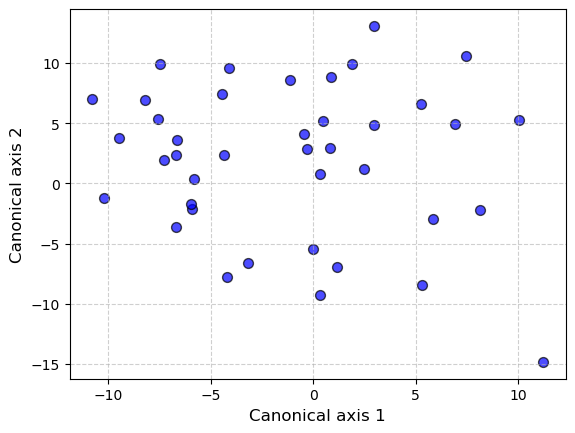

In [ ]:
proj = model.predict(Xpredict)
fig, ax = plt.subplots()
scatter = ax.scatter(proj[:, 0], proj[:, 1], c='blue', edgecolor='k', alpha=0.7, s=50)
ax.set_xlabel('Canonical axis 1', fontsize=12)
ax.set_ylabel('Canonical axis 2', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()


Finally, we can predict the genomic offset under two different environments: 

In [ ]:
#| export 
@patch
def genomic_offset(self:RDA,
        X: np.ndarray, # Environmental matrix (nxP)
        Xstar: np.ndarray, # Altered environmental matrix (nxP)
           )-> np.ndarray: # A vector of genomic offsets (n)
    "Calculates the genomic offset statistic. " 
    if X.shape != Xstar.shape: 
        raise ValueError("Dimensions of array don't match")
    offset = np.zeros(X.shape[0])
    diff = self.predict(X) - self.predict(Xstar)
    weights = self._pca.eigenvals / np.sum(self._pca.eigenvals)
    L = self._reg.params.shape[1]
    for distance, w in zip(diff.T, weights):
        offset += distance**2*w/L
    return offset
    

As expected, the genomic offset is zero if both environmental matrixes are identical: 

In [ ]:
model.genomic_offset(Xpredict, Xpredict)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0.])

In [ ]:
offset = model.genomic_offset(Xpredict, Xpredict+rng.normal(size=Xpredict.shape))
offset

array([4.92357911e-03, 3.32915955e-03, 2.08255362e-03, 6.85551726e-04,
       1.69879388e-03, 1.29574627e-02, 5.25032017e-04, 3.81877626e-03,
       2.19073321e-03, 4.94097972e-03, 1.35313392e-03, 5.11396626e-03,
       5.58329793e-03, 3.41665386e-03, 8.23240168e-03, 5.91416640e-04,
       2.81347588e-03, 3.74435644e-03, 5.03381998e-04, 1.06139414e-02,
       1.30278264e-02, 2.26649053e-03, 2.99553206e-03, 1.63758928e-05,
       2.45834552e-03, 1.79033776e-04, 4.45603830e-04, 1.53036609e-04,
       2.67947979e-03, 1.11264680e-02, 3.29556971e-03, 1.11013314e-02,
       4.47265660e-03, 6.10795441e-03, 1.25497111e-03, 8.70051040e-03,
       1.67001336e-02, 6.44847731e-03, 4.17171529e-03, 3.17151162e-04])

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()